# Bayesian Inference: OPV light-intensity dependant JV fits with SIMsalabim (fake data)
This notebook is a demonstration of how to fit light-intensity dependent JV curves with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.

In [1]:
# Import necessary libraries
import warnings, os, sys, shutil
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import torch, copy, uuid
import pySIMsalabim as sim
from pySIMsalabim.experiments.JV_steady_state import *
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../..') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *

[INFO 04-27 12:46:36] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 04-27 12:46:36] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Define the parameters for the simulation

In [2]:
params = [] # list of parameters to be optimized

mun = FitParam(name = 'l2.mu_n', value = 7e-8, bounds = [1e-9,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 5e-8, bounds = [1e-9,1e-6], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\mu_p$', unit=r'm$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1e20, bounds = [1e19,1e22], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$N_{T}$', unit=r'm$^{-3}$', axis_type = 'log', force_log = True)
params.append(bulk_tr)

preLangevin = FitParam(name = 'l2.preLangevin', value = 1e-2, bounds = [0.005,1], log_scale = True, value_type = 'float', fscale = None, rescale = False, display_name=r'$\gamma_{pre}$', unit=r'', axis_type = 'log', force_log = True)
params.append(preLangevin)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-5,1e-3], log_scale = True, value_type = 'float', fscale = None, rescale = False,  display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', force_log = True)
params.append(R_series)

# save the original parameters for later
params_orig = copy.deepcopy(params)

## Generate some fake data
Here we generate some fake data to fit. The data is generated using the same model as the one used for the fitting, so it is a good test of the fitting procedure. For more information on how to run SIMsalabim from python see the [pySIMsalabim](https://github.com/kostergroup/pySIMsalabim) package.

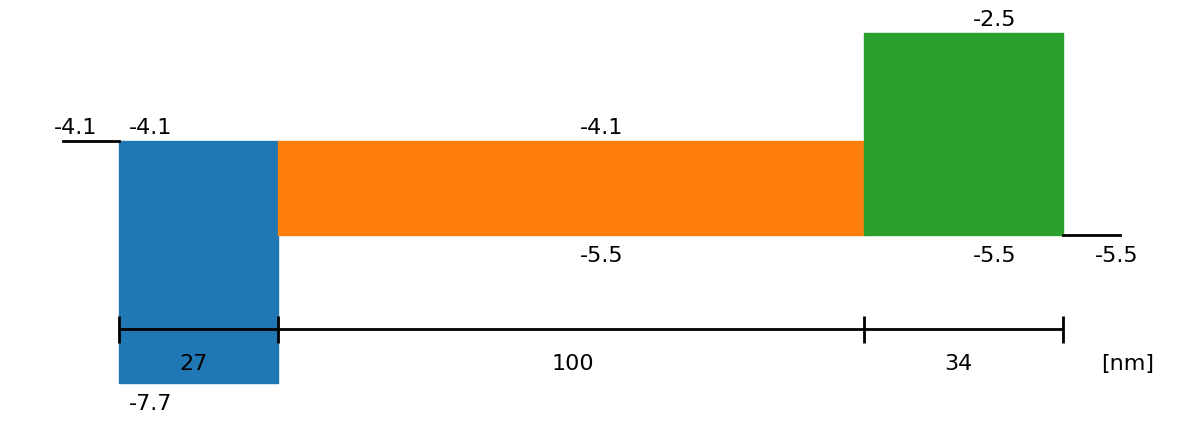

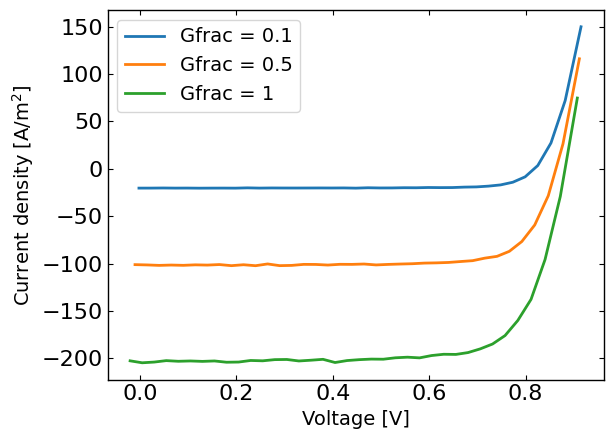

In [3]:
# Set the session path for the simulation and the input files
session_path = os.path.join(os.path.join(os.path.abspath('../..'),'SIMsalabim','SimSS'))
input_path = os.path.join(os.path.join(os.path.join(os.path.abspath('../..'),'Data','simsalabim_test_inputs','fakeOPV')))
simulation_setup_filename = 'simulation_setup_fakeOPV.txt'
simulation_setup = os.path.join(session_path, simulation_setup_filename) 

# path to the layer files defined in the simulation_setup file
l1 = 'ZnO.txt'
l2 = 'ActiveLayer.txt'
l3 = 'BM_HTL.txt'
l1 = os.path.join(input_path, l1)
l2 = os.path.join(input_path, l2)
l3 = os.path.join(input_path, l3)

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path):
    os.makedirs(session_path)
for file in [l1,l2,l3,simulation_setup_filename]:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))
    else:
        print('File already exists: ',file)

# Show the device structure
fig = sim.plot_band_diagram(simulation_setup, session_path)

# reset simss
# Set the JV parameters
Gfracs = [0.1,0.5,1] # Fractions of the generation rate to simulate (None if you want only one light intensity as define in the simulation_setup file)
UUID = str(uuid.uuid4()) # random UUID to avoid overwriting files

cmd_pars = [] # see pySIMsalabim documentation for the command line parameters
# Add the parameters to the command line arguments
for param in params:
    cmd_pars.append({'par':param.name, 'val':str(param.value)})

# Run the JV simulation
ret, mess = run_SS_JV(simulation_setup, session_path, JV_file_name = 'JV.dat', G_fracs = Gfracs, parallel = True, max_jobs = 3, UUID=UUID, cmd_pars=cmd_pars)

# save data for fitting
X,y = [],[]
X_orig,y_orig = [],[]
if Gfracs is None:
    data = pd.read_csv(os.path.join(session_path, 'JV_'+UUID+'.dat'), sep=r'\s+') # Load the data
    Vext = np.asarray(data['Vext'].values)
    Jext = np.asarray(data['Jext'].values)
    G = np.ones_like(Vext)
    rng = default_rng()#
    noise = rng.standard_normal(Jext.shape) * 0.01 * Jext
    Jext = Jext + noise
    X = Vext
    y = Jext

    plt.figure()
    plt.plot(X,y)
    plt.show()
else:
    for Gfrac in Gfracs:
        data = pd.read_csv(os.path.join(session_path, 'JV_Gfrac_'+str(Gfrac)+'_'+UUID+'.dat'), sep=r'\s+') # Load the data
        Vext = np.asarray(data['Vext'].values)
        Jext = np.asarray(data['Jext'].values)
        G = np.ones_like(Vext)*Gfrac
        rng = default_rng()#
        noise = rng.standard_normal(Jext.shape) * 0.005 * Jext

        if len(X) == 0:
            X = np.vstack((Vext,G)).T
            y = Jext + noise
            y_orig = Jext 
        else:
            X = np.vstack((X,np.vstack((Vext,G)).T))
            y = np.hstack((y,Jext+ noise))
            y_orig = np.hstack((y_orig,Jext))

    # remove all the current where Jext is higher than a given value
    X = X[y<200]
    X_orig = copy.deepcopy(X)
    y_orig = y_orig[y<200]
    y = y[y<200]
    
    

    plt.figure()
    for Gfrac in Gfracs:
        plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac))
    plt.xlabel('Voltage [V]')
    plt.ylabel('Current density [A/m$^2$]')
    plt.legend()
    plt.show()



## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.models.DDfits.JVAgent import JVAgent
metric = 'mse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'

# create a different params list for the agent
params_agent = copy.deepcopy(params)
#select a random value between the bounds, we do this because the walkers will be randomly initialized from the param.value
for param in params_agent:
    if param.force_log:
        param.value =10**np.random.uniform(np.log10(param.bounds[0]),np.log10(param.bounds[1]))
    else:
        param.value = np.random.uniform(param.bounds[0],param.bounds[1])
 
jv = JVAgent(params, X, y, session_path, simulation_setup, parallel = True, max_jobs = 3, metric = metric, loss = loss)

# Calulate the target metric for the original parameters
best_fit_possible = loss_function(calc_metric(y,y_orig, metric_name = metric),loss)
print('Best fit: ',best_fit_possible)

Best fit:  0.3260998253420907


## MCMC Bayesian Inference for Parameter Fitting
We'll use the `emcee` package to perform Markov Chain Monte Carlo sampling to find the posterior distribution of our model parameters.

In [5]:
# from optimpv.optimizers.BayesInfEmcee.EmceeOptimizer import EmceeOptimizer
from optimpv.optimizers.BayesInfUltraNest.UltraNestOptimizer import UltraNestOptimizer
# Define the Bayesian Inference object
optimizer = UltraNestOptimizer(
    params=params,
    agents=jv,
    progress=True,
    log_dir='ultranest_logs/jv',
    resume='subfolder', # can be True, False, 'subfolder', or 'overwrite'
    name='ultranest_jv',
    save_logs=False,
    run_kwargs={
        'min_num_live_points': 100,
        'min_ess': 100,
        'max_ncalls': 20000,
    },
)

In [6]:

res = optimizer.optimize()

[INFO 04-27 12:46:36] optimpv.UltraNestOptimizer: Running UltraNest nested sampling...


----------------------------------------------------

[ultranest] Sampling 100 live points from prior ...


[ultranest] Explored until L=-0.3   [-1.3005..-0.9439] | it/evals=988/20185 eff=4.9191% N=100         0  
[ultranest] Likelihood function evaluations: 20185
[ultranest] Reached maximum number of likelihood calls (20185 > 20000)...
[ultranest] done iterating.


[INFO 04-27 13:36:51] optimpv.UltraNestOptimizer: UltraNest run complete.
[INFO 04-27 13:36:51] optimpv.UltraNestOptimizer: $\mu_n$ (l2.mu_n): 5.668e-08 (+6.34e-08 / -2e-08)
[INFO 04-27 13:36:51] optimpv.UltraNestOptimizer: $\mu_p$ (l2.mu_p): 4.96e-08 (+6.34e-08 / -1.99e-08)
[INFO 04-27 13:36:51] optimpv.UltraNestOptimizer: $N_{T}$ (l2.N_t_bulk): 4.358e+19 (+8.2e+19 / -2.71e+19)
[INFO 04-27 13:36:51] optimpv.UltraNestOptimizer: $\gamma_{pre}$ (l2.preLangevin): 0.009693 (+0.00375 / -0.00337)
[INFO 04-27 13:36:51] optimpv.UltraNestOptimizer: $R_{series}$ (R_series): 9.12e-05 (+4.5e-05 / -5.61e-05)


----------------------------------------------------



In [7]:
optimizer.sampler.print_results()


logZ = -9.627 +- 0.752
  single instance: logZ = -9.627 +- 0.276
  bootstrapped   : logZ = -9.574 +- 0.695
  tail           : logZ = +- 0.286
insert order U test : converged: True correlation: inf iterations

    l2.mu_n             : -7.75 │ ▁▁▁▁▂▂▃▄▆▄▇▇▆▇▇▅▄▄▆▅▅▃▃▄▂▃▂▃▂▃▄▂▂▁▁ ▁ │-6.53     -7.19 +- 0.24
    l2.mu_p             : -7.83 │ ▁▁▁▃▄▃▃▅▅▇▆▅▆▅▆▄▃▄▄▄▇▃▃▃▃▃▂▂▃▂▃▁▂▃▁▁▁ │-6.51     -7.25 +- 0.27
    l2.N_t_bulk         : 19.00 │▃▆▅▇▂▅▃▄▄▆▄▆▅▄▅▅▃▇▄▅▄▆▃▃▅▃▅▅▄▂▂▃▂▁▁  ▁ │20.64     19.65 +- 0.38
    l2.preLangevin      : -2.30 │▃▅▄▄▃▅▄▄▄▆▄▇▄▄▃▅▅▇▆▄▆▇▇▃▄▄▄▄▃▁▂▂▂▂   ▁ │-1.61     -2.02 +- 0.15
    R_series            : -5.00 │▁▁▁▁▁▁▁▁▁▁▂▁▁▂▂▁▁▂▃▃▂▂▃▄▂▄▄▆▆▇▄▄▄▄▂▁▁▁ │-3.60     -4.13 +- 0.29



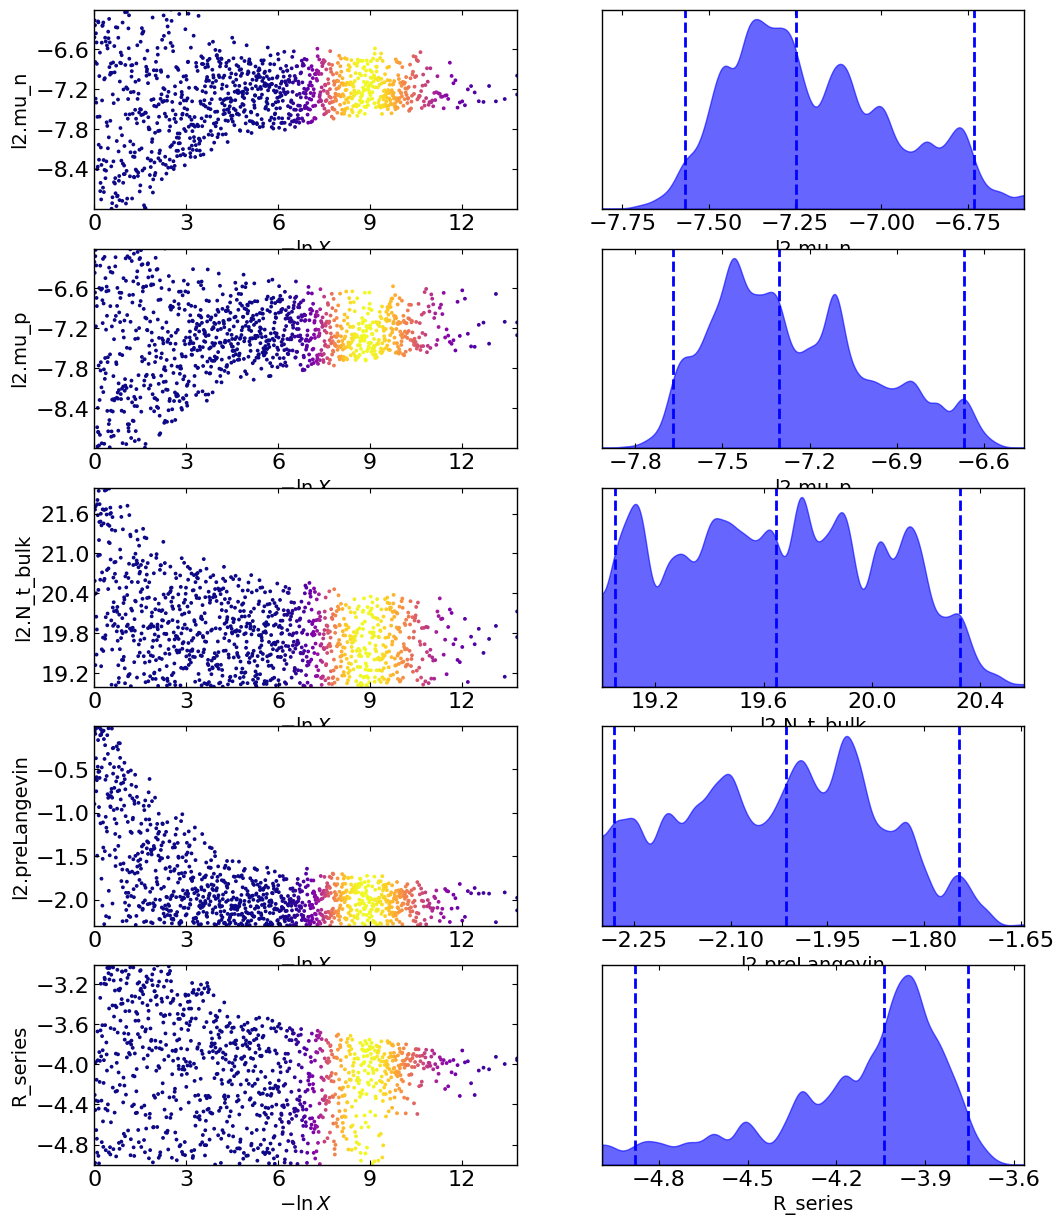

In [8]:
optimizer.sampler.plot_trace()

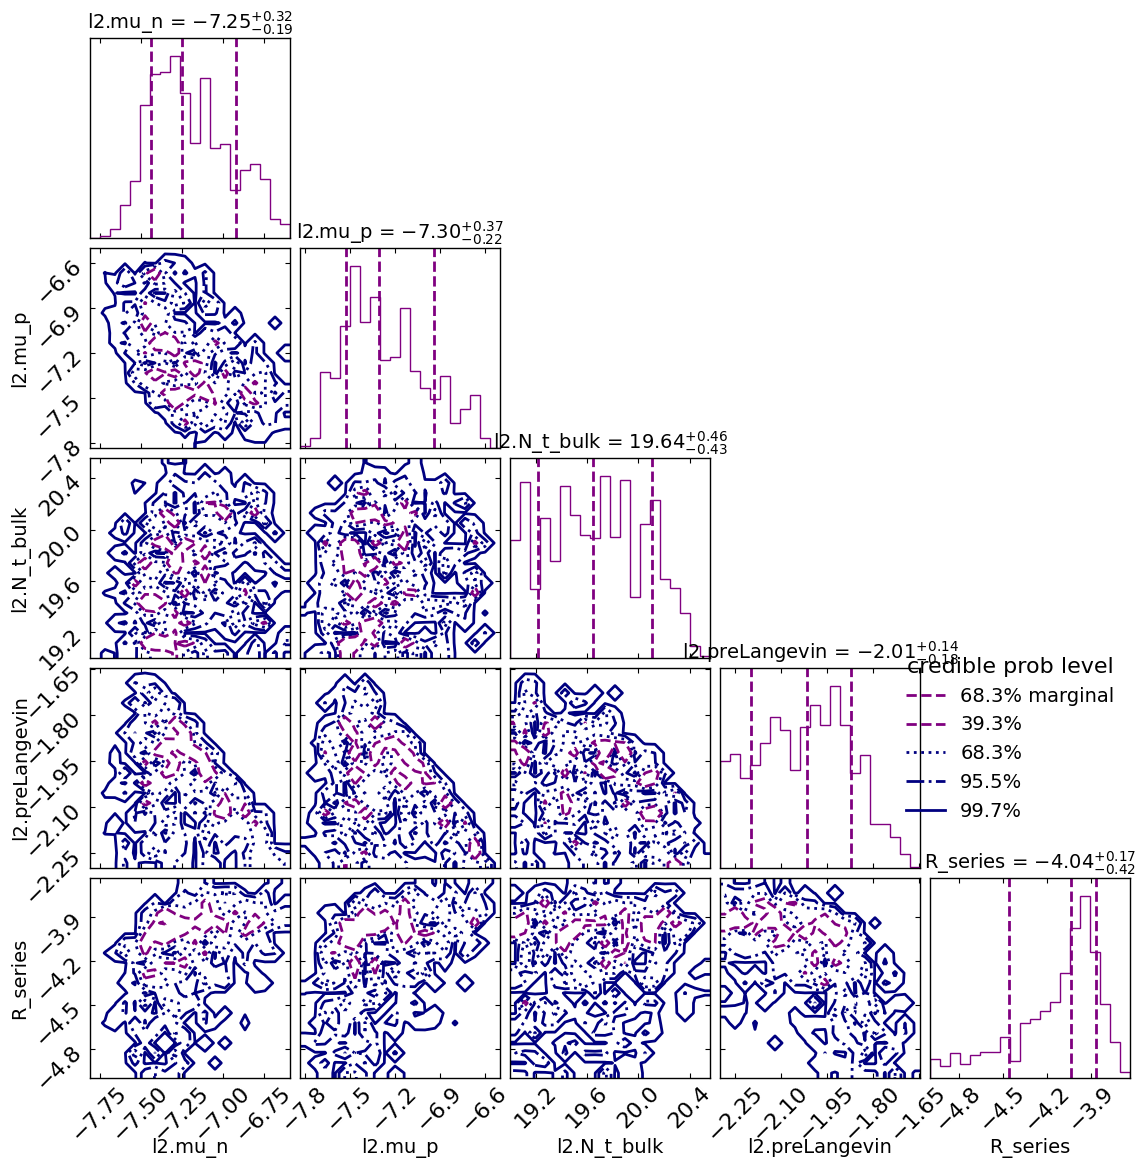

In [14]:
from ultranest.plot import cornerplot
plot = cornerplot(optimizer.nested_result)

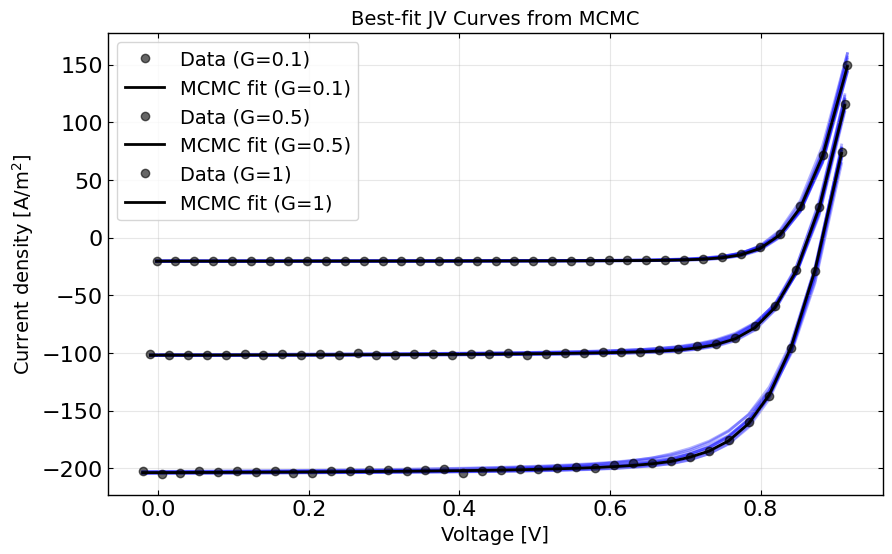

In [10]:
# Run simulation with best-fit parameters
best_fit_params = copy.deepcopy(optimizer.params)

# Create agent with best-fit parameters
best_agent = JVAgent(best_fit_params, X, y, session_path, simulation_setup, 
                     parallel=True, max_jobs=3, metric=metric, loss=loss)

best_fit_y = best_agent.run(parameters={})

# Plot the best-fit curves against data
plt.figure(figsize=(10, 6))
for Gfrac in Gfracs:
    mask = X[:,1] == Gfrac
    plt.plot(X[mask,0], y[mask], 'ko', alpha=0.6, label=f'Data (G={Gfrac})')
    plt.plot(X[mask,0], best_fit_y[mask], 'k-', label=f'MCMC fit (G={Gfrac})')

# add the 10 best fit curves
for i in range(10):
    # prep dum dic
    dum_dic = {}
    # add the parameters
    idx = 0
    for param in params:
        if param.type != 'fixed':
            dum_dic[param.name] = optimizer.flat_samples[i][idx]
            idx += 1
  
    y_ = best_agent.run(parameters=dum_dic)
    for Gfrac in Gfracs:
        mask = X[:,1] == Gfrac
        plt.plot(X[mask,0], y_[mask], 'b-', alpha=0.3, zorder = -1)

plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A/m$^2$]')
plt.legend()
plt.title('Best-fit JV Curves from MCMC')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path)
sim.delete_folders('tmp',session_path)
# uncomment the following lines to delete specific files
sim.clean_up_output('ZnO',session_path)
sim.clean_up_output('ActiveLayer',session_path)
sim.clean_up_output('BM_HTL',session_path)
sim.clean_up_output('simulation_setup_fakeOPV',session_path)